In [1]:
import pandas as pd
import itertools
from sklearn.metrics import cohen_kappa_score
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [2]:
df = pd.read_excel("C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/data/raw/Données_Marchés_publics_2024.xlsx")

In [3]:
df.drop(['Comportement déclaratif dans les DSF par rapport au cumul mensuel en 2024', 'ident', 'Type_de_centre',
           'Conformité de déclaration de marchés en 2019', 'Conformité de déclaration de marchés en 2020',
           'Conformité de déclaration de marchés en 2021', 'Conformité de déclaration de marchés en 2022',
           'SBTP', 'SERM', 'SFBME', 'SPSOE', 'STLM', 'Actif2024',
           'MinCA19', 'MinCA20', 'MinCA21', 'MinCA22', 'MinCA19_23'], axis=1, inplace=True)

In [4]:
df.select_dtypes('number').columns

Index(['MontantMP24'], dtype='object')

In [5]:
colonnes_binaires = ['Regime', 'gctax (groupe de compte de gestion des contribuables)', 'Type de déclarant des MP dans les DSF', 'Persojuri']

colonnes_multimodales = ['Nbprestation_marchés', 'Typedemarché', 'Conformité de déclaration de marchés en 2023']

In [6]:
colonnes_num = df.select_dtypes('number').columns

In [7]:
df.loc[df['Fraude'] == 'Risque faible', 'Fraude'] = 'Risqué'
df.loc[df['Fraude'] == 'Risque élevé', 'Fraude'] = 'Risqué'

In [8]:
df['Fraude'].value_counts()

Fraude
Risqué           6087
Pas de risque    5711
Name: count, dtype: int64

In [9]:
# Division
from sklearn.model_selection import train_test_split

def split(data):
    X = data.drop('Fraude', axis=1)
    y = data['Fraude']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
    
    return X_train, X_test, y_train, y_test

In [10]:
X_train, X_test, y_train, y_test = split(df)

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(9438, 10)
(2360, 10)
(9438,)
(2360,)


In [12]:
X_train

,Regime,Persojuri,gctax (groupe de compte de gestion des contribuables),Type de déclarant des MP dans les DSF,Conformité de déclaration de marchés en 2023,MinCA23,Nbprestation_marchés,Typedemarché,MontantMP24,DSF23
5527,REEL,Physique,Petits comptes,Déclarants permanents,MD,Non,Plus de deux marchés,Bons_commande,1854980,Oui
1853,IGS,Physique,Petits comptes,Déclarants permanents,MD,Non,Un marché,Bons_commande,1350000,Oui
913,REEL,Physique,Petits comptes,Déclarants permanents,NPC,Non,Deux marchés,Mixte,9999606,Oui
5364,REEL,Physique,Petits comptes,Déclarants permanents,NPC,Non,Un marché,Bons_commande,1114219,Oui
5312,REEL,Physique,Petits comptes,Déclarants permanents,MD,Non,Deux marchés,Bons_commande,1761619,Oui
...,...,...,...,...,...,...,...,...,...,...
8718,REEL,Physique,Grands comptes,Déclarants permanents,MD,Non,Un marché,Bons_commande,2999830,Oui
4691,REEL,Physique,Petits comptes,Déclarants permanents,NPC,Non,Plus de deux marchés,Bons_commande,5499780,Oui
11352,IGS,Physique,Grands comptes,Défaillants,MD,Non,Un marché,Bons_commande,1488240,Non
5725,REEL,Physique,Petits comptes,Déclarants permanents,MD,Oui,Un marché,Bons_commande,1062492,Oui


In [13]:
for col in df.select_dtypes('object').columns:
    print(f'{col:-<50}{df[col].unique()}')

Regime--------------------------------------------['IGS' 'REEL']
Persojuri-----------------------------------------['Morale' 'Physique']
gctax (groupe de compte de gestion des contribuables)['Petits comptes' 'Grands comptes']
Type de déclarant des MP dans les DSF-------------['Déclarants permanents' 'Défaillants']
Conformité de déclaration de marchés en 2023------['MD' 'NPC' 'MND']
MinCA23-------------------------------------------['Non' 'Oui']
Nbprestation_marchés------------------------------['Plus de deux marchés' 'Un marché' 'Deux marchés']
Typedemarché--------------------------------------['Bons_commande' 'Lettre_commande&Marchés' 'Mixte']
DSF23---------------------------------------------['Oui' 'Non']
Fraude--------------------------------------------['Risqué' 'Pas de risque']


In [14]:
df.columns

Index(['Regime', 'Persojuri',
       'gctax (groupe de compte de gestion des contribuables)',
       'Type de déclarant des MP dans les DSF',
       'Conformité de déclaration de marchés en 2023', 'MinCA23',
       'Nbprestation_marchés', 'Typedemarché', 'MontantMP24', 'DSF23',
       'Fraude'],
      dtype='object')

In [15]:
dico = {
    "pas de risque": 0,
    "risqué": 1
    #"risque élevé": 2
}
y_train_enc = y_train.str.strip().str.lower().map(dico)
y_test_enc = y_test.str.strip().str.lower().map(dico)

In [16]:
y_train_enc.value_counts()

Fraude
1    4869
0    4569
Name: count, dtype: int64

## Apprentissage supervisé

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('binary_cols', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), colonnes_binaires),
        ('multimodal_cols', OneHotEncoder(handle_unknown="ignore", sparse_output=False), colonnes_multimodales),
        ('num', 'passthrough', colonnes_num)
    ],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

In [18]:
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm 
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [19]:
# Initialisation de l'estimateur
brf = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', BalancedRandomForestClassifier())
])

lr = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression())
])

xgb = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', XGBClassifier(learning_rate=0.1, n_estimators=1000, random_state=2, max_depth=1))
])

lgb = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LGBMClassifier(learning_rate=0.1, n_estimators=1000, random_state=2, max_depth=1, verbose=-1))
])

In [20]:
models = {
    "Balanced RF": brf,
    "Logistic Regression": lr,
    "Xgboost": xgb,
    "Light gradient boosting": lgb
}

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, roc_auc_score, roc_curve, f1_score
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

In [22]:
def evaluation(model, X_train, X_test, y_train, y_test):
    
    # Entrainement 
    model.fit(X_train, y_train)
    
    # predictions
    y_pred = model.predict(X_test)

    #kappa = cohen_kappa_score(y_test, y_pred, weights='quadratic')
    auc = roc_auc_score(y_test, y_pred)

    # evaluation
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    #print(f"Quadratic weighted kappa:-------> {kappa}")
    print(f"AUC------------------> {auc}")

    kfold = StratifiedKFold(n_splits=4, shuffle=True)
    # Courbe d'apprentissage
    N, trainscore, valscore = learning_curve(model, X_train, y_train, cv=kfold, scoring='f1_weighted', train_sizes=[0.25, 0.50, 0.75, 1.00])

    plt.figure()
    plt.plot(N, trainscore.mean(axis=1), label='Entrainement')
    plt.plot(N, valscore.mean(axis=1), label='Validation')
    plt.xlabel("Taille des données d'entrainement")
    plt.ylabel("f1_score")
    plt.legend()
    plt.show()

========================Balanced RF=====================================
[[687 455]
 [446 772]]
              precision    recall  f1-score   support

           0       0.61      0.60      0.60      1142
           1       0.63      0.63      0.63      1218

    accuracy                           0.62      2360
   macro avg       0.62      0.62      0.62      2360
weighted avg       0.62      0.62      0.62      2360

AUC------------------> 0.6177010631536871


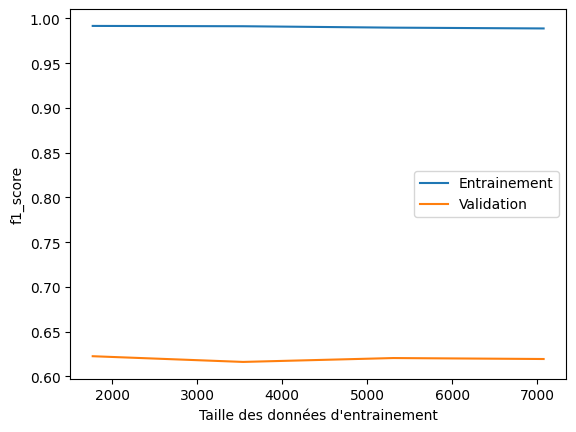

========================Logistic Regression=====================================
[[   0 1142]
 [   0 1218]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1142
           1       0.52      1.00      0.68      1218

    accuracy                           0.52      2360
   macro avg       0.26      0.50      0.34      2360
weighted avg       0.27      0.52      0.35      2360

AUC------------------> 0.5


c:\Users\DELL\Documents\VEMV\pycaret\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\Documents\VEMV\pycaret\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\DELL\Documents\VEMV\pycaret\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


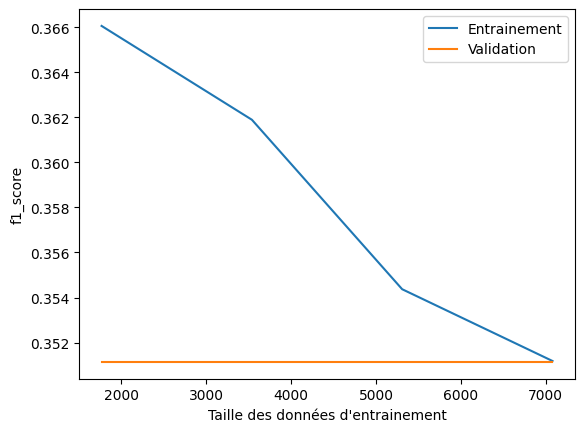

========================Xgboost=====================================
[[774 368]
 [370 848]]
              precision    recall  f1-score   support

           0       0.68      0.68      0.68      1142
           1       0.70      0.70      0.70      1218

    accuracy                           0.69      2360
   macro avg       0.69      0.69      0.69      2360
weighted avg       0.69      0.69      0.69      2360

AUC------------------> 0.6869908178260132


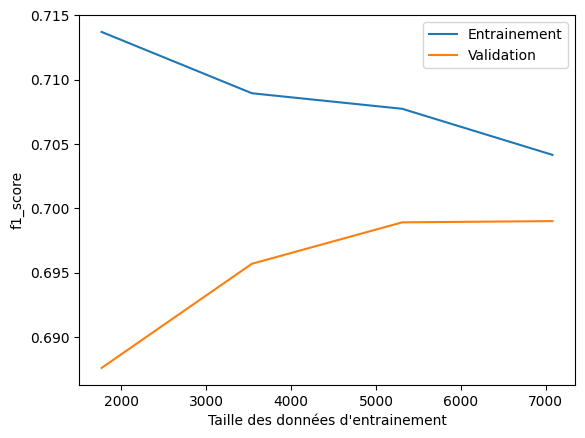

========================Light gradient boosting=====================================
[[769 373]
 [376 842]]
              precision    recall  f1-score   support

           0       0.67      0.67      0.67      1142
           1       0.69      0.69      0.69      1218

    accuracy                           0.68      2360
   macro avg       0.68      0.68      0.68      2360
weighted avg       0.68      0.68      0.68      2360

AUC------------------> 0.6823386217824288


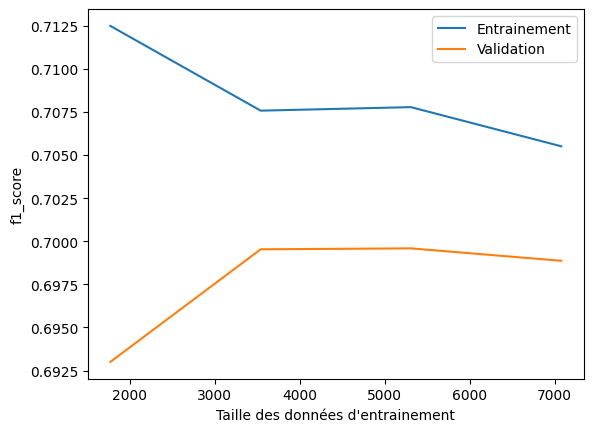

In [23]:
for name, model in models.items():
    print(f'========================{name}=====================================')
    evaluation(model, X_train, X_test, y_train_enc, y_test_enc)

C:\Users\DELL\AppData\Local\Temp\ipykernel_15892\2387448276.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


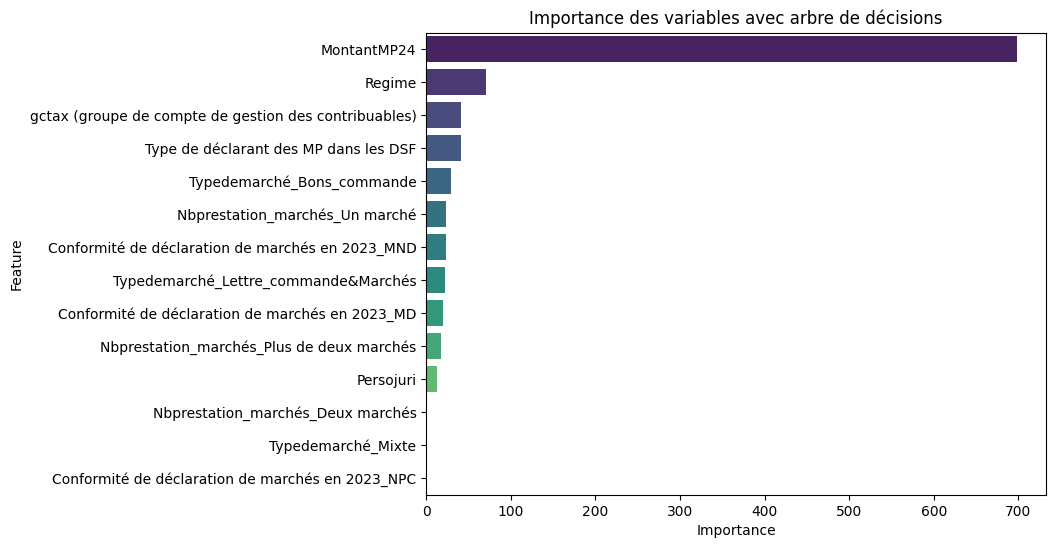

In [24]:
import seaborn as sns

# importance des variables
classifier = lgb.named_steps['classifier']

importances = classifier.feature_importances_
# Récupérer le ColumnTransformer
preprocessor = model.named_steps['preprocessing']

# Obtenir les noms des features après transformation
names = preprocessor.get_feature_names_out()

df_importances = pd.DataFrame({
    "Feature": names,
    "Importance": importances
})

# Trier par importance décroissante
df_importances = df_importances.sort_values(by="Importance", ascending=False)

# Barplot classé
plt.figure(figsize=(8,6))
sns.barplot(
    data=df_importances,
    x="Importance", 
    y="Feature", 
    palette="viridis"
)
plt.title('Importance des variables avec arbre de décisions')
plt.savefig('C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/outputs/figures/Figures modélisation/Importance_variables_classification_binaire.png')

In [25]:
xgb

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('binary_cols',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Regime',
                                                   'gctax (groupe de compte de '
                                                   'gestion des contribuables)',
                                                   'Type de déclarant des MP '
                                                   'dans les DSF',
                                                   'Persojuri']),
                                                 ('multimodal_cols',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Nbprestation...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=1, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=1000, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [26]:
import pickle

#with open('modele_binaire.pkl', 'wb') as f:
#    pickle.dump(xgb, f)

Text(0.5, 1.0, 'Matrice de Confusion')

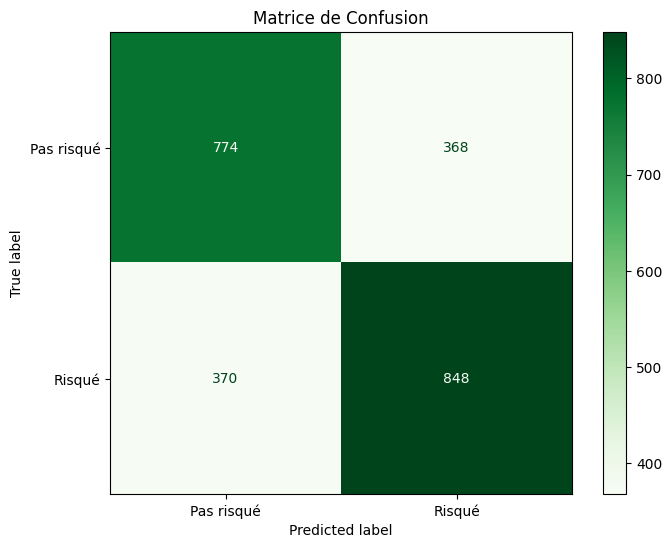

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = xgb.predict(X_test)

# classification report
report = classification_report(y_test_enc, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()


# Création de la visualisation
cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pas risqué', 'Risqué'])

# Personnalisation et affichage
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Greens', ax=ax, values_format='d')  # 'd' pour afficher des entiers
plt.title('Matrice de Confusion')
#plt.savefig('C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/outputs/figures/Figures modélisation/Matrice_de_confusion_classification_binaire.png')

In [28]:
#df_report.to_excel('C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/outputs/metrics/rapport de classification_binaire.xlsx')

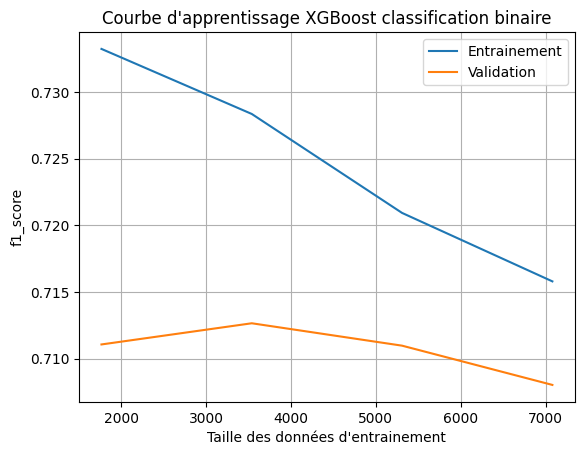

In [29]:
kfold = StratifiedKFold(n_splits=4, shuffle=True)
# Courbe d'apprentissage
N, trainscore, valscore = learning_curve(lgb, X_train, y_train_enc, cv=kfold, scoring='f1', train_sizes=[0.25, 0.50, 0.75, 1.00])

plt.figure()
plt.plot(N, trainscore.mean(axis=1), label='Entrainement')
plt.plot(N, valscore.mean(axis=1), label='Validation')
plt.xlabel("Taille des données d'entrainement")
plt.ylabel("f1_score")
plt.title("Courbe d'apprentissage XGBoost classification binaire")
plt.legend()
plt.grid()
#plt.savefig("C:/Users/DELL/Documents/VEMV/business/work/DETECTION_DE_FRAUDES_FISCALES/outputs/figures/Figures modélisation/courbe_d'apprentissage_class_binaire.png")
plt.show()

In [30]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Extraire le modèle final du pipeline
# Supposons que votre pipeline s'appelle 'lgb' et que le classificateur est la dernière étape
final_model = xgb.named_steps['classifier']  # Remplacez 'classifier' par le nom de l'étape de votre modèle dans le pipeline

# 2. Initialiser l'explainer avec le modèle extrait
explainer = shap.TreeExplainer(final_model)

# 3. Préparer les données d'entraînement pré-traitées (sans les transformations finales du modèle)
# Extraire les transformations de préprocessing du pipeline
preprocessing_steps = xgb[:-1]  # Toutes les étapes sauf la dernière
X_train_processed = preprocessing_steps.transform(X_train)  # Transformations appliquées aux données d'entraînement

# 4. Calculer les valeurs SHAP pour l'ensemble de test pré-traité
X_test_processed = preprocessing_steps.transform(X_test)
shap_values = explainer.shap_values(X_test_processed)

# 5. ANALYSE GLOBALE
print("Analyse Globale avec SHAP")

# Graphique en barres (importance moyenne)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_processed, plot_type="bar", show=False)
plt.title("Importance Globale des Variables (SHAP)")
plt.tight_layout()
plt.savefig('shap_global_importance(binary classif).png')
plt.show()

# Graphique beeswarm (impact des valeurs)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_processed, show=False, plot_type="violin")
#plt.title("Impact des valeurs des variables sur le score de risque (SHAP)")
plt.tight_layout()
plt.savefig('shap_summary_plot(binary classif).png')
plt.show()


ModuleNotFoundError: No module named 'shap'

## Aprentissage non supervisé

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model 

### Isolation forest

In [32]:
iforest = IsolationForest(contamination=0.5)

iforest = Pipeline([
    ('preprocessing', preprocessor),
    ('model', iforest)
])


In [33]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [34]:
import numpy as np

iforest.fit(X_train)
y_pred_iforest = iforest.predict(X_test)
y_pred_iforest = np.where(y_pred_iforest == -1, 1, 0)

print("Isolation forest :")
print("Accuracy: ", accuracy_score(y_test_enc, y_pred_iforest))
print(classification_report(y_test_enc, y_pred_iforest))
print(confusion_matrix(y_test_enc, y_pred_iforest))

Isolation forest :
Accuracy:  0.5169491525423728
              precision    recall  f1-score   support

           0       0.50      0.51      0.51      1142
           1       0.53      0.52      0.53      1218

    accuracy                           0.52      2360
   macro avg       0.52      0.52      0.52      2360
weighted avg       0.52      0.52      0.52      2360

[[586 556]
 [584 634]]


## Autoencodeur

In [35]:
class AutoencoderTransformer:
    def __init__(self, encoding_dim):
        self.encoding_dim = encoding_dim
        self.autoencoder = None
        self.history = None
    
    def fit(self, X, y=None):
        # Convertir en numpy si DataFrame
        if hasattr(X, "to_numpy"):
            X = X.to_numpy()
        input_dim = 14
        input_layer = Input(shape=(input_dim,))
        encoder = Dense(7, activation='relu')(input_layer)
        encoder2 = Dense(self.encoding_dim, activation='relu')(encoder)
        decoder = Dense(7, activation='relu')(encoder2)
        decoder2 = Dense(input_dim, activation='linear')(decoder)
        self.autoencoder = Model(inputs=input_layer, outputs=decoder2)
        self.autoencoder.compile(optimizer='adam', loss='mean_squared_error')
        self.history = self.autoencoder.fit(X, X, epochs=30, batch_size=32, shuffle=True, validation_split=0.2)
        return self
    
    def transform(self, X):
        if hasattr(X, "to_numpy"):
            X = X.to_numpy()
        return self.autoencoder.predict(X)

In [36]:
autoencoder = Pipeline([
    ('preprocessing', preprocessor),
    ('scaling', StandardScaler()),
    ('autoencoder', AutoencoderTransformer(encoding_dim=7))
])

In [37]:
autoencoder

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('binary_cols',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Regime',
                                                   'gctax (groupe de compte de '
                                                   'gestion des contribuables)',
                                                   'Type de déclarant des MP '
                                                   'dans les DSF',
                                                   'Persojuri']),
                                                 ('multimodal_cols',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Nbprestation_marchés',
                                                   'Typedemarché',
                                                   'Conformité de déclaration '
                                                   'de marchés en 2023']),
                                                 ('num', 'passthrough',
                                                  Index(['MontantMP24'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('scaling', StandardScaler()),
                ('autoencoder',
                 <__main__.AutoencoderTransformer object at 0x000001C09006FBB0>)])

In [38]:
# Entrainement
autoencoder.fit(X_train)




Epoch 1/30

236/236 [==============================] - 4s 5ms/step - loss: 0.9048 - val_loss: 0.9146
Epoch 2/30
236/236 [==============================] - 1s 3ms/step - loss: 0.7176 - val_loss: 0.7268
Epoch 3/30
236/236 [==============================] - 1s 3ms/step - loss: 0.5665 - val_loss: 0.6246
Epoch 4/30
236/236 [==============================] - 1s 3ms/step - loss: 0.4933 - val_loss: 0.5589
Epoch 5/30
236/236 [==============================] - 1s 4ms/step - loss: 0.4279 - val_loss: 0.5172
Epoch 6/30
236/236 [==============================] - 1s 3ms/step - loss: 0.4003 - val_loss: 0.5008
Epoch 7/30
236/236 [==============================] - 1s 3ms/step - loss: 0.3856 - val_loss: 0.4894
Epoch 8/30
236/236 [==============================] - 1s 4ms/step - loss: 0.3771 - val_loss: 0.4825
Epoch 9/30
236/236 [==============================] - 1s 4ms/step - loss: 0.3713 - val_loss: 0.4783
Epoch 10/30
236/236 [==============================] - 1s 4ms/step - loss: 0.3673 - val_loss: 0.4

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('binary_cols',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Regime',
                                                   'gctax (groupe de compte de '
                                                   'gestion des contribuables)',
                                                   'Type de déclarant des MP '
                                                   'dans les DSF',
                                                   'Persojuri']),
                                                 ('multimodal_cols',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Nbprestation_marchés',
                                                   'Typedemarché',
                                                   'Conformité de déclaration '
                                                   'de marchés en 2023']),
                                                 ('num', 'passthrough',
                                                  Index(['MontantMP24'], dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('scaling', StandardScaler()),
                ('autoencoder',
                 <__main__.AutoencoderTransformer object at 0x000001C09006FBB0>)])

In [39]:
# Utiliser l'erreur de reconstruction pour detecter les fraudes
# Passe X_test dans le pipeline sans l'autoencoder
X_test_processed = autoencoder[:-1].transform(X_test)   # (2360, 14)

# Reconstruction par l’autoencodeur
X_test_reconstructed = autoencoder.transform(X_test)   # (2360, 14)

# Erreur de reconstruction
reconstruction_error = np.mean((X_test_processed - X_test_reconstructed) ** 2, axis=1)

threshold = np.percentile(reconstruction_error, 48)
y_pred_autoencoder = np.where(reconstruction_error > threshold, 1, 0)

74/74 [==============================] - 0s 2ms/step


Autoencoder :
Accuracy:  0.4961864406779661
              precision    recall  f1-score   support

           0       0.48      0.48      0.48      1142
           1       0.51      0.52      0.51      1218

    accuracy                           0.50      2360
   macro avg       0.50      0.50      0.50      2360
weighted avg       0.50      0.50      0.50      2360

[[543 599]
 [590 628]]


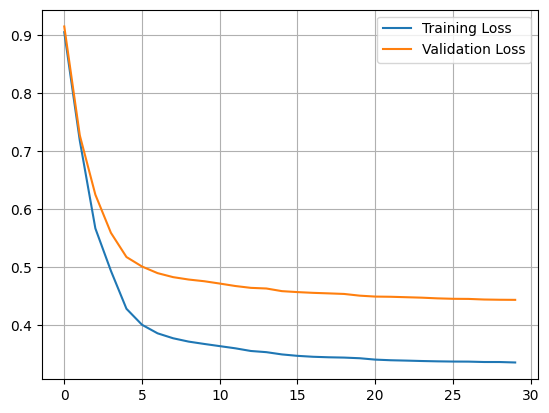

In [40]:
print("Autoencoder :")
print("Accuracy: ", accuracy_score(y_test_enc, y_pred_autoencoder))
print(classification_report(y_test_enc, y_pred_autoencoder))
print(confusion_matrix(y_test_enc, y_pred_autoencoder))
plt.plot(autoencoder.named_steps['autoencoder'].history.history['loss'], label='Training Loss')
plt.plot(autoencoder.named_steps['autoencoder'].history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.grid()
plt.show()